In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import json
import re

from node2vec import Node2Vec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset

from random import randint



DEBUG = True
RAW_DATA_PATH = 'Sim_Raw_data.parquet'
GRAPH_DATA_PATH = 'Sim_Graph.json'
SAVE_PATH_3 = "TRAINED/GMAN_model_reconstruct.pth"

SAMPLING = '1h'
MONTHS_HISTORY = 8

# CREATION GRAPH

In [2]:
with open(GRAPH_DATA_PATH, 'r') as f:
    G_router_json = json.load(f)

G_router = nx.node_link_graph(G_router_json)


NODE_LIST = list(G_router.nodes())
EDGE_LIST = list(G_router.edges())
NUM_NODES = len(NODE_LIST)
NUM_EDGES = len(EDGE_LIST)

print("NUmber of nodes: ", NUM_NODES)
print("NUmber of edges: ", NUM_EDGES)
print(f"NODE_LIST: {NODE_LIST} ")
print(f"EDGE_LIST: {EDGE_LIST}")

NODE_TO_IDX = {node: idx for idx, node in enumerate(NODE_LIST)}
IDX_TO_NODE = {idx: node for idx, node in enumerate(NODE_LIST)}

NUmber of nodes:  16
NUmber of edges:  16
NODE_LIST: ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4'] 
EDGE_LIST: [('HR_A', 'MR_A'), ('MR_A', 'C'), ('HR_B', 'MR_B'), ('MR_B', 'MR_A'), ('MR_B', 'A'), ('C', 'D'), ('C', 'S7'), ('D', 'E'), ('D', 'S6'), ('D', 'S5'), ('A', 'B'), ('A', 'S1'), ('A', 'S2'), ('B', 'D'), ('B', 'S3'), ('E', 'S4')]


# DATA PREPARATION

In [3]:
DATA_RAW_MODEL = pd.read_parquet(RAW_DATA_PATH)
DATA_RAW_MODEL = DATA_RAW_MODEL.resample(SAMPLING).mean()

## 8 Months history
DATA_RAW_MODEL = DATA_RAW_MODEL[DATA_RAW_MODEL.index.month.isin(DATA_RAW_MODEL.index.month.unique()[-MONTHS_HISTORY:])]
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL = DATA_RAW_MODEL[NODE_LIST]

display(DATA_RAW_MODEL)


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-01-01 00:00:00,4.05,4.05,9.73,9.73,4.05,3.81,5.68,4.13,0.80,0.24,0.28,2.74,0.32,1.52,0.03,0.80
2024-01-01 01:00:00,3.13,3.13,9.49,9.49,3.13,3.13,6.36,3.29,0.80,0.00,0.28,2.05,0.16,3.04,0.03,0.80
2024-01-01 02:00:00,7.26,7.26,20.61,20.61,7.26,7.10,13.35,7.26,0.80,0.16,0.83,5.47,0.16,6.09,0.00,0.80
2024-01-01 03:00:00,18.44,18.44,50.27,50.27,18.44,17.97,31.83,18.13,4.01,0.47,0.28,13.68,0.16,13.70,0.00,4.01
2024-01-01 04:00:00,27.96,27.96,71.11,71.11,27.96,27.09,43.15,27.88,6.42,0.87,2.20,18.47,0.79,15.22,0.05,6.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 19:00:00,861.22,861.22,2645.90,2645.90,861.22,809.22,1784.69,878.87,416.79,52.00,141.74,250.69,69.65,883.82,22.00,416.79
2024-06-28 20:00:00,544.12,544.12,1748.09,1748.09,544.12,503.77,1203.97,549.01,232.06,40.35,99.70,172.01,45.24,638.55,16.41,232.06
2024-06-28 21:00:00,229.89,229.89,758.65,758.65,229.89,208.01,528.76,227.51,116.79,21.88,44.80,46.42,19.49,291.70,9.55,116.79
2024-06-28 22:00:00,56.25,56.25,215.79,215.79,56.25,48.08,159.54,52.81,24.43,8.17,8.50,15.15,4.73,103.04,3.69,24.43


# PARAMETERS

In [4]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

# DATASET PARAMS
FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
FREQ_MINUTES = FREQ_H*60
NUM_NODES = len(NODE_LIST)
HIST_STEPS = int(14*(24/FREQ_H))          # 4 day
PRED_STEPS = int(4*(24/FREQ_H))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 128


PATCH_LEN = 16
PATCH_STRIDE = 8


STEPS_PER_DAY = int(24/FREQ_H)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 4
D_HEADS = int(D_MODEL/K_HEADS)

print(f"Frequency: {FREQ_H} hours")
print(f"Frequency: {FREQ_MINUTES} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEADS}")

Frequency: 1 hours
Frequency: 60 minutes
Number of nodes: 16
Number of historical steps: 336
Number of prediction steps: 96
Number of time features: 43
Input dimension: 1
Output dimension: 1
Model dimension: 128
Steps per day: 24
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 4
Dimension of each head: 32


# DATASETS / DATALOADERS

In [5]:
class TimeSeriesDataset(Dataset):
    """
    A PyTorch Dataset for time series forecasting using sliding windows.
    """
    def __init__(self, data, seq_len, pred_len, stride=1):
        """
        Args:
            data (np.ndarray or torch.Tensor): The continuous time series data of shape (Total_Time_Steps, Channels).
            seq_len (int): The length of the look-back window (L).
            pred_len (int): The length of the prediction horizon (T).
            stride (int): How many steps to move the window forward for each sample. 
                          Use stride=1 for maximum data overlap (standard for training).
        """
        # Ensure data is a torch float32 tensor
        if isinstance(data, np.ndarray):
            self.data = torch.from_numpy(data).float()
        else:
            self.data = data.float()
            
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.stride = stride
        
        # Calculate how many valid windows we can extract
        self.num_samples = (len(self.data) - self.seq_len - self.pred_len) // self.stride + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        # Calculate the starting index of the sequence based on the stride
        start_idx = index * self.stride
        
        # End of the look-back window / Start of the prediction window
        end_idx = start_idx + self.seq_len
        
        # End of the prediction window
        pred_end_idx = end_idx + self.pred_len
        
        # Extract X (Input sequence) and Y (Target sequence)
        X = self.data[start_idx : end_idx, :]
        Y = self.data[end_idx : pred_end_idx, :]
        
        return X, Y



total_timesteps = DATA_RAW_MODEL.shape[0]
split_idx = int(total_timesteps * 0.8)
train_raw_data = DATA_RAW_MODEL.values[:split_idx]
val_raw_data = DATA_RAW_MODEL.values[split_idx - HIST_STEPS:]


TRAIN_DS = TimeSeriesDataset(train_raw_data, seq_len=HIST_STEPS, pred_len=PRED_STEPS)
VAL_DS = TimeSeriesDataset(val_raw_data, seq_len=HIST_STEPS, pred_len=PRED_STEPS)

TRAIN_DL = DataLoader(TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
VAL_DL = DataLoader(VAL_DS, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"TRAIN_DL: {len(TRAIN_DL)}")
print(f"VAL_DL: {len(VAL_DL)}")


if DEBUG:

    X,Y = next(iter(TRAIN_DL))
    print(f"X.shape: {X.shape}")
    print(f"Y.shape: {Y.shape}")

TRAIN_DL: 94
VAL_DL: 24
X.shape: torch.Size([32, 336, 16])
Y.shape: torch.Size([32, 96, 16])


# MODEL
## PATCHTST

In [6]:
class PatchTST(nn.Module):
    def __init__(self, seq_len, pred_len, patch_len=16, stride=8, 
                 d_model=128, n_heads=16, e_layers=3, d_ff=256, dropout=0.2):
        super().__init__()
        
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.patch_len = patch_len
        self.stride = stride
        
        # Calculate the number of patches N = floor((L - P) / S) + 2
        # Padding by S repeated numbers of the last value adds an extra patch
        self.patch_num = int((seq_len - patch_len) / stride) + 2
        
        # Padding layer: pads the sequence with S repeated last values
        self.padding_patch_layer = nn.ReplicationPad1d((0, stride))
        
        # 1. Linear Projection (W_p)
        self.value_embedding = nn.Linear(patch_len, d_model)
        
        # 2. Positional Embedding (W_pos)
        self.position_embedding = nn.Parameter(torch.randn(1, self.patch_num, d_model))
        
        # 3. Transformer Encoder Backbone
        # Note: The paper mentions using BatchNorm instead of LayerNorm in the transformer 
        # blocks for time series, but standard PyTorch implementations use LayerNorm. 
        # We use the standard PyTorch LayerNorm-based TransformerEncoder here for simplicity.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_ff, 
            dropout=dropout, 
            activation='gelu', 
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=e_layers)
        
        # 4. Flatten and Linear Head for final forecasting
        self.head = nn.Linear(self.patch_num * d_model, pred_len)

    def forward(self, x):
        # Input shape: (Batch, Sequence_Length, Channels)
        B, L, M = x.shape
        
        # --- Instance Normalization ---
        # Normalize each univariate time series with zero mean and unit variance
        means = x.mean(dim=1, keepdim=True).detach()
        x = x - means
        stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + 1e-5).detach()
        x /= stdev
        
        # --- Channel-Independence ---
        # Permute to (Batch, Channels, Sequence_Length)
        x = x.permute(0, 2, 1) 
        
        # --- Patching ---
        # Pad S repeated numbers of the last value to the end of the original sequence
        x = self.padding_patch_layer(x)
        
        # Unfold sequence into patches. 
        # Shape becomes: (Batch, Channels, Num_Patches, Patch_Length)
        x = x.unfold(dimension=-1, size=self.patch_len, step=self.stride)
        
        # Fold the Batch and Channel dimensions together to process independently
        # Shape becomes: (Batch * Channels, Num_Patches, Patch_Length)
        x = x.reshape(B * M, self.patch_num, self.patch_len)
        
        # --- Projection & Positional Embedding ---
        x = self.value_embedding(x) + self.position_embedding
        
        # --- Transformer Encoder ---
        x = self.encoder(x)
        
        # --- Flattening & Linear Head ---
        # Flatten patches: (Batch * Channels, Num_Patches * d_model)
        x = x.reshape(B * M, -1)
        
        # Project to prediction length: (Batch * Channels, Prediction_Length)
        x = self.head(x)
        
        # --- Reshape back ---
        # Reshape to (Batch, Channels, Prediction_Length)
        x = x.reshape(B, M, self.pred_len)
        # Permute to (Batch, Prediction_Length, Channels)
        x = x.permute(0, 2, 1)
        
        # --- De-Normalization ---
        # Add the mean and variance back to the output prediction
        x = x * stdev
        x = x + means
        
        return x

if DEBUG:
    from random import randint

    stride = 8
    patch_len = 16
    seq_len = HIST_STEPS
    pred_len = PRED_STEPS
    
    e_layers = LAYERS_ENC_DEC
    d_ff = 256
    dropout = 0.2
    

    patch_num = int((seq_len - patch_len) / stride) + 2

    padding_patch_layer = nn.ReplicationPad1d((0, stride))
    value_embedding = nn.Linear(patch_len, D_MODEL)
    position_embedding = nn.Parameter(torch.randn(1, patch_num, D_MODEL))
    encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, 
            nhead=K_HEADS, 
            dim_feedforward=d_ff, 
            dropout=dropout, 
            activation='gelu', 
            batch_first=True
        )
    encoder = nn.TransformerEncoder(encoder_layer, num_layers=e_layers)
    head = nn.Linear(patch_num * D_MODEL, pred_len)

    for X,Y in TRAIN_DL:
        if randint(0,100) == 3:
            break

    print(f"X.shape: {X.shape}")
    print(f"Y.shape: {Y.shape}")

    B, L, M = X.shape
        

    means = X.mean(dim=1, keepdim=True).detach()
    print(f"means.shape: {means.shape}")

    X = X - means
    stdev = torch.sqrt(torch.var(X, dim=1, keepdim=True, unbiased=False) + 1e-5).detach()
    print(f"stdev.shape: {stdev.shape}")
    X /= stdev
    print()
    X = X.permute(0, 2, 1) 
    print(f"X.shape: {X.shape}")
    X = padding_patch_layer(X)
    print(f"X.shape after padding: {X.shape}")
    X = X.unfold(dimension=-1, size=patch_len, step=stride)
    print(f"X.shape after unfold: {X.shape}")
    X = X.reshape(B * M, patch_num, patch_len)
    print(f"X.shape after reshape: {X.shape}")
    X = value_embedding(X) + position_embedding
    print(f"X.shape after embedding: {X.shape}")
    X = encoder(X)
    print(f"X.shape after encoder: {X.shape}")
    X = X.reshape(B * M, -1)
    print(f"X.shape after reshape: {X.shape}")
    X = head(X)
    print(f"X.shape after head: {X.shape}")
    X = X.reshape(B, M, pred_len)
    print(f"X.shape after reshape: {X.shape}")
    X = X.permute(0, 2, 1)
    print(f"X.shape after permute: {X.shape}")

    X = X * stdev
    X = X + means
    print(f"X.shape after denormalization: {X.shape}")

X.shape: torch.Size([32, 336, 16])
Y.shape: torch.Size([32, 96, 16])
means.shape: torch.Size([32, 1, 16])
stdev.shape: torch.Size([32, 1, 16])

X.shape: torch.Size([32, 16, 336])
X.shape after padding: torch.Size([32, 16, 344])
X.shape after unfold: torch.Size([32, 16, 42, 16])
X.shape after reshape: torch.Size([512, 42, 16])
X.shape after embedding: torch.Size([512, 42, 128])
X.shape after encoder: torch.Size([512, 42, 128])
X.shape after reshape: torch.Size([512, 5376])
X.shape after head: torch.Size([512, 96])
X.shape after reshape: torch.Size([32, 16, 96])
X.shape after permute: torch.Size([32, 96, 16])
X.shape after denormalization: torch.Size([32, 96, 16])


# TRAINNIG

In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {DEVICE}")

Training on: cuda


In [8]:
def train_model(model, train_loader, val_loader, epochs=10, learning_rate=1e-4, device='cuda'):
    """
    Trains the PatchTST model using MSE Loss.
    """
    model.to(device)
    
    # The paper uses MSE loss to measure the discrepancy between prediction and ground truth.
    # By default, nn.MSELoss() in PyTorch averages the loss across all elements (batch size, prediction length, and channels), 
    # which matches the paper's objective of gathering and averaging loss over the M time series.
    criterion = nn.MSELoss() 
    
    # Adam is a standard choice for Transformer-based architectures
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        total_train_loss = 0.0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            # 1. Zero the gradients
            optimizer.zero_grad()
            
            # 2. Forward pass
            predictions = model(batch_x)
            
            # 3. Calculate loss
            loss = criterion(predictions, batch_y)
            
            # 4. Backward pass and optimization
            loss.backward()
            optimizer.step()
            
            total_train_loss += loss.item() * batch_x.size(0)
            
        avg_train_loss = total_train_loss / len(train_loader.dataset)
        
        # --- Validation Phase ---
        model.eval()
        total_val_loss = 0.0
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                
                predictions = model(batch_x)
                loss = criterion(predictions, batch_y)
                
                total_val_loss += loss.item() * batch_x.size(0)
                
        avg_val_loss = total_val_loss / len(val_loader.dataset)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss (MSE): {avg_train_loss:.4f} | Val Loss (MSE): {avg_val_loss:.4f}")

    return model

### TRAINING PROCESS

In [9]:
   
DIR_TRAINED = "TRAINED_MODELS"

## MODEL ZERO  (MSE ONLY)

In [79]:
MODEL = PatchTST(
        seq_len=HIST_STEPS, 
        pred_len=PRED_STEPS,
        patch_len=PATCH_LEN,
        stride=PATCH_STRIDE,
        d_model=D_MODEL,
        n_heads=K_HEADS,
        e_layers=LAYERS_ENC_DEC,
    ).to(DEVICE)



PREFIX_MODEL = 'patchtst_model_zero'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")


optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = nn.MSELoss()

Checkpoint path: TRAINED_MODELS/best_patchtst_model_zero.pth


In [80]:
MODEL = train_model(
    MODEL, 
    TRAIN_DL, 
    VAL_DL, 
    epochs=EPOCHS, 
    learning_rate=LR, 
    device=DEVICE
)



OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Epoch [1/30] | Train Loss (MSE): 76408.7860 | Val Loss (MSE): 16654.1095
Epoch [2/30] | Train Loss (MSE): 17304.0300 | Val Loss (MSE): 17696.9965
Epoch [3/30] | Train Loss (MSE): 16257.5638 | Val Loss (MSE): 17253.0999
Epoch [4/30] | Train Loss (MSE): 15086.8341 | Val Loss (MSE): 16202.1108
Epoch [5/30] | Train Loss (MSE): 13634.6231 | Val Loss (MSE): 15727.8890
Epoch [6/30] | Train Loss (MSE): 13134.7308 | Val Loss (MSE): 14573.5153
Epoch [7/30] | Train Loss (MSE): 12471.8253 | Val Loss (MSE): 15314.0057
Epoch [8/30] | Train Loss (MSE): 12088.1049 | Val Loss (MSE): 14268.0945
Epoch [9/30] | Train Loss (MSE): 11739.3574 | Val Loss (MSE): 13801.0150
Epoch [10/30] | Train Loss (MSE): 11528.1961 | Val Loss (MSE): 13381.4082
Epoch [11/30] | Train Loss (MSE): 11264.2317 | Val Loss (MSE): 13475.7403
Epoch [12/30] | Train Loss (MSE): 11010.5476 | Val Loss (MSE): 13031.6963
Epoch [13/30] | Train Loss (MSE): 10809.9664 | Val Loss (MSE): 13435.6068
Epoch [14/30] | Train Loss (MSE): 10892.3404 | 

# VALIDATION MODELS

In [15]:

import math
import matplotlib.pyplot as plt

def validate_model(model, val_loader, device='cuda'):
    """
    Validates the time series forecasting model calculating MAE, RMSE, and MAPE.
    
    Args:
        model (nn.Module): The trained PyTorch model (e.g., PatchTST).
        val_loader (DataLoader): DataLoader containing the validation/test data.
        device (str): Device to run the validation on ('cuda' or 'cpu').
        
    Returns:
        tuple: (MAE, RMSE, MAPE)
    """
    # Ensure the model is in evaluation mode (disables dropout, etc.)
    model.eval()
    model.to(device)
    
    total_absolute_error = 0.0
    total_squared_error = 0.0
    total_percentage_error = 0.0
    
    # We count the total number of predicted elements across all batches, 
    # horizons, and channels to calculate an accurate global average.
    total_elements = 0 
    
    # Epsilon to prevent division by zero in MAPE calculation
    epsilon = 1e-7 

    # Disable gradient calculation for memory efficiency and speed
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            # Get model predictions
            predictions = model(batch_x)
            
            # 1. Absolute Error (for MAE)
            abs_err = torch.abs(predictions - batch_y)
            total_absolute_error += torch.sum(abs_err).item()
            
            # 2. Squared Error (for RMSE)
            sq_err = torch.square(predictions - batch_y)
            total_squared_error += torch.sum(sq_err).item()
            
            # 3. Absolute Percentage Error (for MAPE)
            # We divide the absolute error by the absolute ground truth value
            abs_pct_err = abs_err / (torch.abs(batch_y) + epsilon)
            total_percentage_error += torch.sum(abs_pct_err).item()
            
            # Count elements in this batch (Batch_Size * Pred_Len * Channels)
            total_elements += batch_y.numel()

    # Calculate final aggregated metrics
    mae = total_absolute_error / total_elements
    rmse = math.sqrt(total_squared_error / total_elements)
    mape = (total_percentage_error / total_elements) * 100  # Convert to percentage

    print("-" * 30)
    print("Validation Results:")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.4f}%")
    print("-" * 30)
    
    return mae, rmse, mape


import matplotlib.pyplot as plt
import torch
import random

def plot_random_channel_prediction(model, data_loader, device='cuda'):
    """
    Takes a single batch from the DataLoader, runs the model, picks a random 
    sample and a random channel, and plots the historical input, ground truth, and prediction.
    
    Args:
        model (nn.Module): The trained PyTorch model.
        data_loader (DataLoader): DataLoader containing the validation/test data.
        device (str): Device to run the inference on ('cuda' or 'cpu').
    """
    model.eval()
    model.to(device)
    
    # Grab one batch of data
    batch_x, batch_y = next(iter(data_loader))
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
    
    # Run the model to get predictions
    with torch.no_grad():
        predictions = model(batch_x)
        
    # Move tensors to CPU and convert to numpy for matplotlib
    batch_x = batch_x.cpu().numpy()
    batch_y = batch_y.cpu().numpy()
    predictions = predictions.cpu().numpy()
    
    # Get dimensions
    batch_size, seq_len, num_channels = batch_x.shape
    pred_len = batch_y.shape[1]
    
    # Select a random sample from the batch and a random channel
    sample_idx = random.randint(0, batch_size - 1)
    channel_idx = random.randint(0, num_channels - 1)
    
    # Extract the sequences for the selected sample and channel
    history = batch_x[sample_idx, :, channel_idx]
    truth = batch_y[sample_idx, :, channel_idx]
    pred = predictions[sample_idx, :, channel_idx]
    
    # Create x-axis time steps
    t_history = range(seq_len)
    t_future = range(seq_len, seq_len + pred_len)
    
    # --- Plotting ---
    # Clear the current plot just in case
    plt.clf()
    
    # Plot 1: Historical Data (Look-back window)
    plt.plot(t_history, history, label='Historical Input', color='#1f77b4')
    
    # Plot 2: Ground Truth Target (What actually happened)
    plt.plot(t_future, truth, label='Ground Truth', color='#2ca02c')
    
    # Plot 3: Model Prediction (What the model forecasted)
    plt.plot(t_future, pred, label='Model Prediction', color='#d62728', linestyle='--')
    
    # Formatting
    plt.title(f'Prediction vs Ground Truth\n(Sample Index: {sample_idx} | Channel Index: {channel_idx})')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)




### MODEL ZERO

Retrieving model from TRAINED_MODELS/patchtst_model_zero_trained.pth
------------------------------
Validation Results:
MAE:  55.5056
RMSE: 111.6780
MAPE: 51719613.2812%
------------------------------



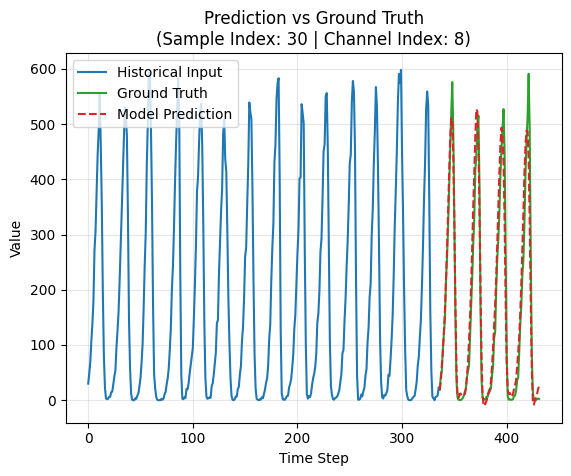

In [17]:
MODEL = PatchTST(
        seq_len=HIST_STEPS, 
        pred_len=PRED_STEPS,
        patch_len=PATCH_LEN,
        stride=PATCH_STRIDE,
        d_model=D_MODEL,
        n_heads=K_HEADS,
        e_layers=LAYERS_ENC_DEC,
    )



PREFIX_MODEL = 'patchtst_model_zero'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)


val_mae, val_rmse, val_mape = validate_model(MODEL, VAL_DL, device='cpu')

plot_random_channel_prediction(MODEL, VAL_DL, device='cpu')

print()